In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [47]:
df_sig = pd.read_csv("sig1000_waves.csv")
df_aviso = pd.read_csv("tide_output_01232025-02192025.csv")
df_ss = pd.read_csv("Shorescan_TWLviewer_AllTransects_01232025-02192025_subset2.csv")

print(df_ss)



     Unnamed: 0  cc_twl  cc_Hs  cc_tide  cc_ru_2pct  ss_ru_2pct  ss_twl_mean  \
0             0   0.788   0.61    0.558        0.37    1.974754     1.037879   
1             1   0.598   0.60    0.368        0.37    1.724754     0.915171   
2             2   0.598   0.60    0.368        0.37    1.724754     0.685692   
3             3   0.388   0.60    0.068        0.51    1.224754     0.242463   
4             4  -0.012   0.59   -0.332        0.51    0.724754    -0.261912   
..          ...     ...    ...      ...         ...         ...          ...   
120           2   0.598   0.60    0.368        0.37    1.456042     0.631980   
121           3   0.388   0.60    0.068        0.51    1.081042     0.396563   
122           4   0.388   0.60    0.068        0.51    0.581042     0.077014   
123           5  -0.332   0.58   -0.642        0.50    0.000000    -0.338925   
124           6  -0.332   0.58   -0.642        0.50    0.000000    -0.243895   

     ss_twl_std  ss_zrunup_mean  ss_zru

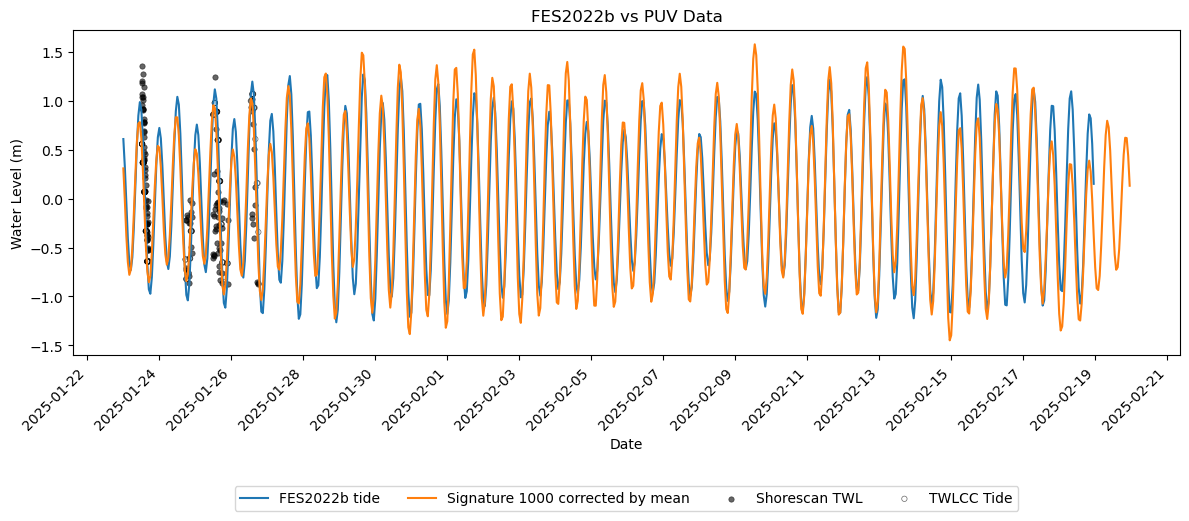

In [46]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
df_sig["time"] = pd.to_datetime(df_sig["time"])
df_aviso["Date"] = pd.to_datetime(df_aviso["Date"])
df_ss["dt0"] = pd.to_datetime(df_ss["dt0"])

df_sig["water_depth_mean"] = df_sig["water_depth"].mean()
df_sig["water_variation"] = df_sig["water_depth"]-df_sig["water_depth_mean"]


fig, ax = plt.subplots(figsize = (12,6))
ax.plot(df_aviso["Date"],df_aviso["Geo_Tide"]/100,label="FES2022b tide") # convert from cm
ax.plot(df_sig["time"],df_sig["water_variation"],label = "Signature 1000 corrected by mean")


ax.scatter(df_ss["dt0"],df_ss["ss_twl_mean"],
           edgecolors="black",
           linewidths=0.5,
           facecolors="black",
           label = "Shorescan TWL",
           s= 15,
           alpha=0.6
           )

ax.scatter(df_ss["dt0"],df_ss["cc_tide"],
           facecolors= "None",
           edgecolors="black",
           linewidths=0.5,
           label = "TWLCC Tide",
           s= 15,
           alpha=0.6
           )

# Set daily ticks and format
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # every day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.50),ncol=4)
ax.set_xlabel("Date")
ax.set_ylabel("Water Level (m)")
ax.set_title("FES2022b vs PUV Data")
plt.tight_layout()
plt.show()

